# Textile Waste Intelligence Platform
# Dataset Analysis & Exploratory Data Analysis (EDA)

## Overview
This notebook performs comprehensive Exploratory Data Analysis (EDA) on both datasets for the Textile Waste Intelligence Platform. The analysis will inform preprocessing decisions, model architecture choices, and training strategies.

### Datasets Being Analyzed
1. **Fabric Classification Dataset (iBUG)** - 25 fabric classes, we'll use 10 selected classes
2. **Fabric Defect Dataset** - 6 defect classes

### Analysis Objectives
- Analyze class distributions and imbalances
- Examine image properties (size, color channels, quality)
- Detect corrupted images and duplicates
- Analyze material compositions
- Provide data-driven recommendations for preprocessing and modeling

### Expected Outputs
- Metadata CSV files for both datasets
- JSON summary of findings
- Professional visualizations
- Comprehensive EDA report

In [ ]:
!pip install -q kaggle
!pip install -q imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.3 MB/s eta 0:00:00


In [ ]:
# Import Libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from collections import Counter, defaultdict

import imagehash

from tqdm import tqdm

plt.style.use("ggplot")

In [65]:
# Kaggle Authentication
#from google.colab import files
#files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d orchit/the-fabrics-dataset-by-ibug
!kaggle datasets download -d nexuswho/fabric-defects-dataset

Dataset URL: https://www.kaggle.com/datasets/orchit/the-fabrics-dataset-by-ibug
License(s): unknown
100% 1.77G/1.77G [00:27<00:00, 69.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/nexuswho/fabric-defects-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.09G/2.09G [00:29<00:00, 76.2MB/s]



In [ ]:
!unzip -q the-fabrics-dataset-by-ibug.zip -d fabrics_dataset
!unzip -q fabric-defects-dataset.zip -d defects_dataset

In [ ]:
FABRIC_DATASET_PATH = "/content/fabrics_dataset"
DEFECT_DATASET_PATH = "/content/defects_dataset"
OUTPUT_PATH = "/content/output"

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [ ]:
print("Fabric Dataset Exists :", os.path.exists(FABRIC_DATASET_PATH))
print("Defect Dataset Exists :", os.path.exists(DEFECT_DATASET_PATH))
print("Output Folder Exists :", os.path.exists(OUTPUT_PATH))

Fabric Dataset Exists : True
Defect Dataset Exists : True
Output Folder Exists : True


In [ ]:
# Explore Dataset Structure
print("Fabric Classes\n")

for folder in sorted(os.listdir(FABRIC_DATASET_PATH)):
    print(folder)


Fabric Classes

Acrylic
Artificial_fur
Artificial_leather
Blended
Chenille
Corduroy
Cotton
Crepe
Denim
Felt
Fleece
Leather
Linen
Lut
Nylon
Polyester
Satin
Silk
Suede
Terrycloth
Unclassified
Utilities
Velvet
Viscose
Wool


In [ ]:
from pathlib import Path

# Check one class folder
sample_class = Path(FABRIC_DATASET_PATH) / "Cotton"

print("Contents of Cotton folder:")
for item in sample_class.iterdir():
    print(item)


Contents of Cotton folder:
/content/fabrics_dataset/Cotton/114
/content/fabrics_dataset/Cotton/1833
/content/fabrics_dataset/Cotton/1202
/content/fabrics_dataset/Cotton/1380
/content/fabrics_dataset/Cotton/1401
/content/fabrics_dataset/Cotton/9
/content/fabrics_dataset/Cotton/211
/content/fabrics_dataset/Cotton/348
/content/fabrics_dataset/Cotton/1801
/content/fabrics_dataset/Cotton/397
/content/fabrics_dataset/Cotton/1514
/content/fabrics_dataset/Cotton/1601
/content/fabrics_dataset/Cotton/320
/content/fabrics_dataset/Cotton/1188
/content/fabrics_dataset/Cotton/1744
/content/fabrics_dataset/Cotton/1219
/content/fabrics_dataset/Cotton/1494
/content/fabrics_dataset/Cotton/456
/content/fabrics_dataset/Cotton/1296
/content/fabrics_dataset/Cotton/839
/content/fabrics_dataset/Cotton/324
/content/fabrics_dataset/Cotton/1510
/content/fabrics_dataset/Cotton/462
/content/fabrics_dataset/Cotton/160
/content/fabrics_dataset/Cotton/232
/content/fabrics_dataset/Cotton/1807
/content/fabrics_dataset/

In [ ]:
from pathlib import Path

sample_class = Path(FABRIC_DATASET_PATH) / "Cotton"

for root, dirs, files in os.walk(sample_class):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:5])
    print("Files:", files[:5])

    # only show first few folders
    if files:
        break


Folder: /content/fabrics_dataset/Cotton
Subfolders: ['114', '1833', '1202', '1380', '1401']
Files: []

Folder: /content/fabrics_dataset/Cotton/114
Subfolders: []
Files: ['im_4.png', 'im_3.png', 'im_1.png', 'im_2.png', 'tag.txt']


In [ ]:
from pathlib import Path
import pandas as pd

fabric_counts = {}
total_images = 0

for class_folder in sorted(Path(FABRIC_DATASET_PATH).iterdir()):

    if class_folder.is_dir():

        image_files = []

        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:

            image_files.extend(class_folder.rglob(ext))

        fabric_counts[class_folder.name] = len(image_files)

        total_images += len(image_files)

fabric_df = pd.DataFrame(
    fabric_counts.items(),
    columns=["Fabric Class", "Number of Images"]
)

fabric_df = fabric_df.sort_values(
    by="Number of Images",
    ascending=False
)

display(fabric_df)

print(f"\nTotal Classes : {len(fabric_df)}")
print(f"Total Images  : {total_images}")

,Fabric Class,Number of Images
6,Cotton,2352
3,Blended,1645
15,Polyester,904
8,Denim,648
20,Unclassified,492
24,Wool,360
14,Nylon,228
17,Silk,200
23,Viscose,148
10,Fleece,132



Total Classes : 25
Total Images  : 7885


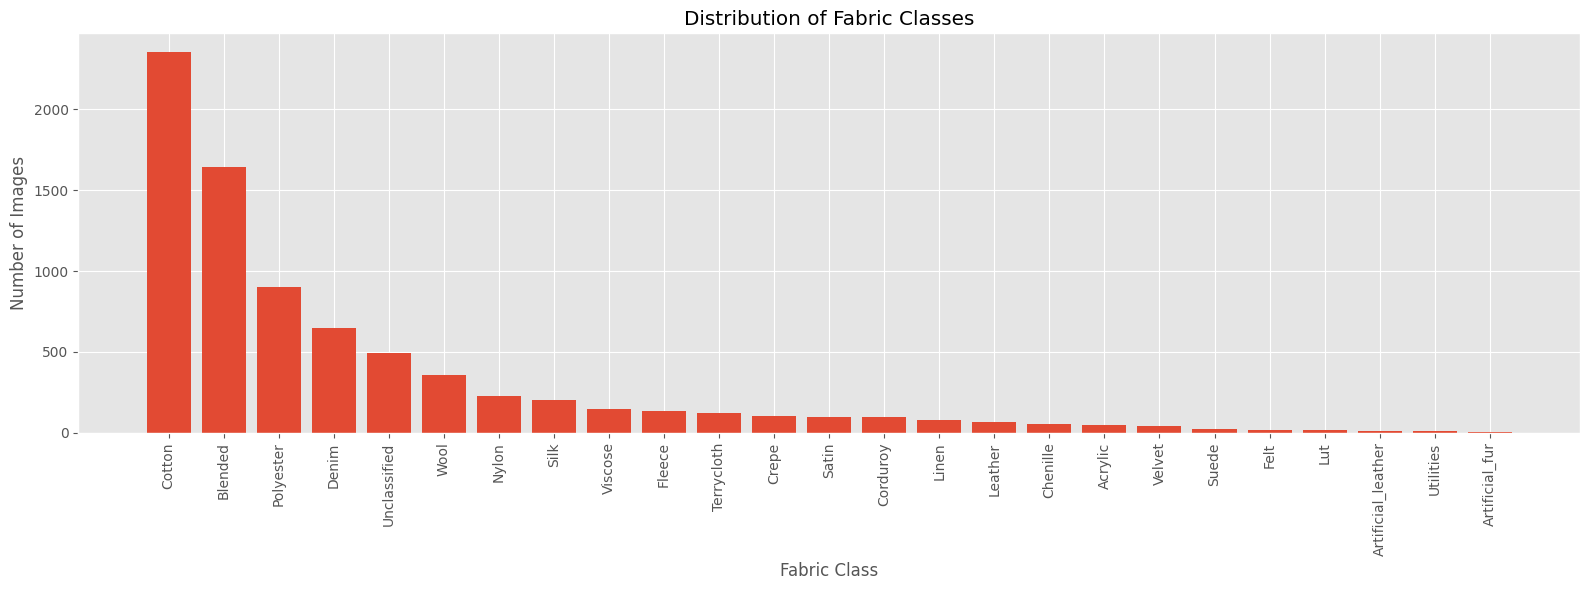

In [ ]:
# Fabric Class Distribution
plt.figure(figsize=(16,6))

plt.bar(
    fabric_df["Fabric Class"],
    fabric_df["Number of Images"]
)

plt.xticks(rotation=90)

plt.xlabel("Fabric Class")
plt.ylabel("Number of Images")

plt.title("Distribution of Fabric Classes")

plt.tight_layout()

plt.show()

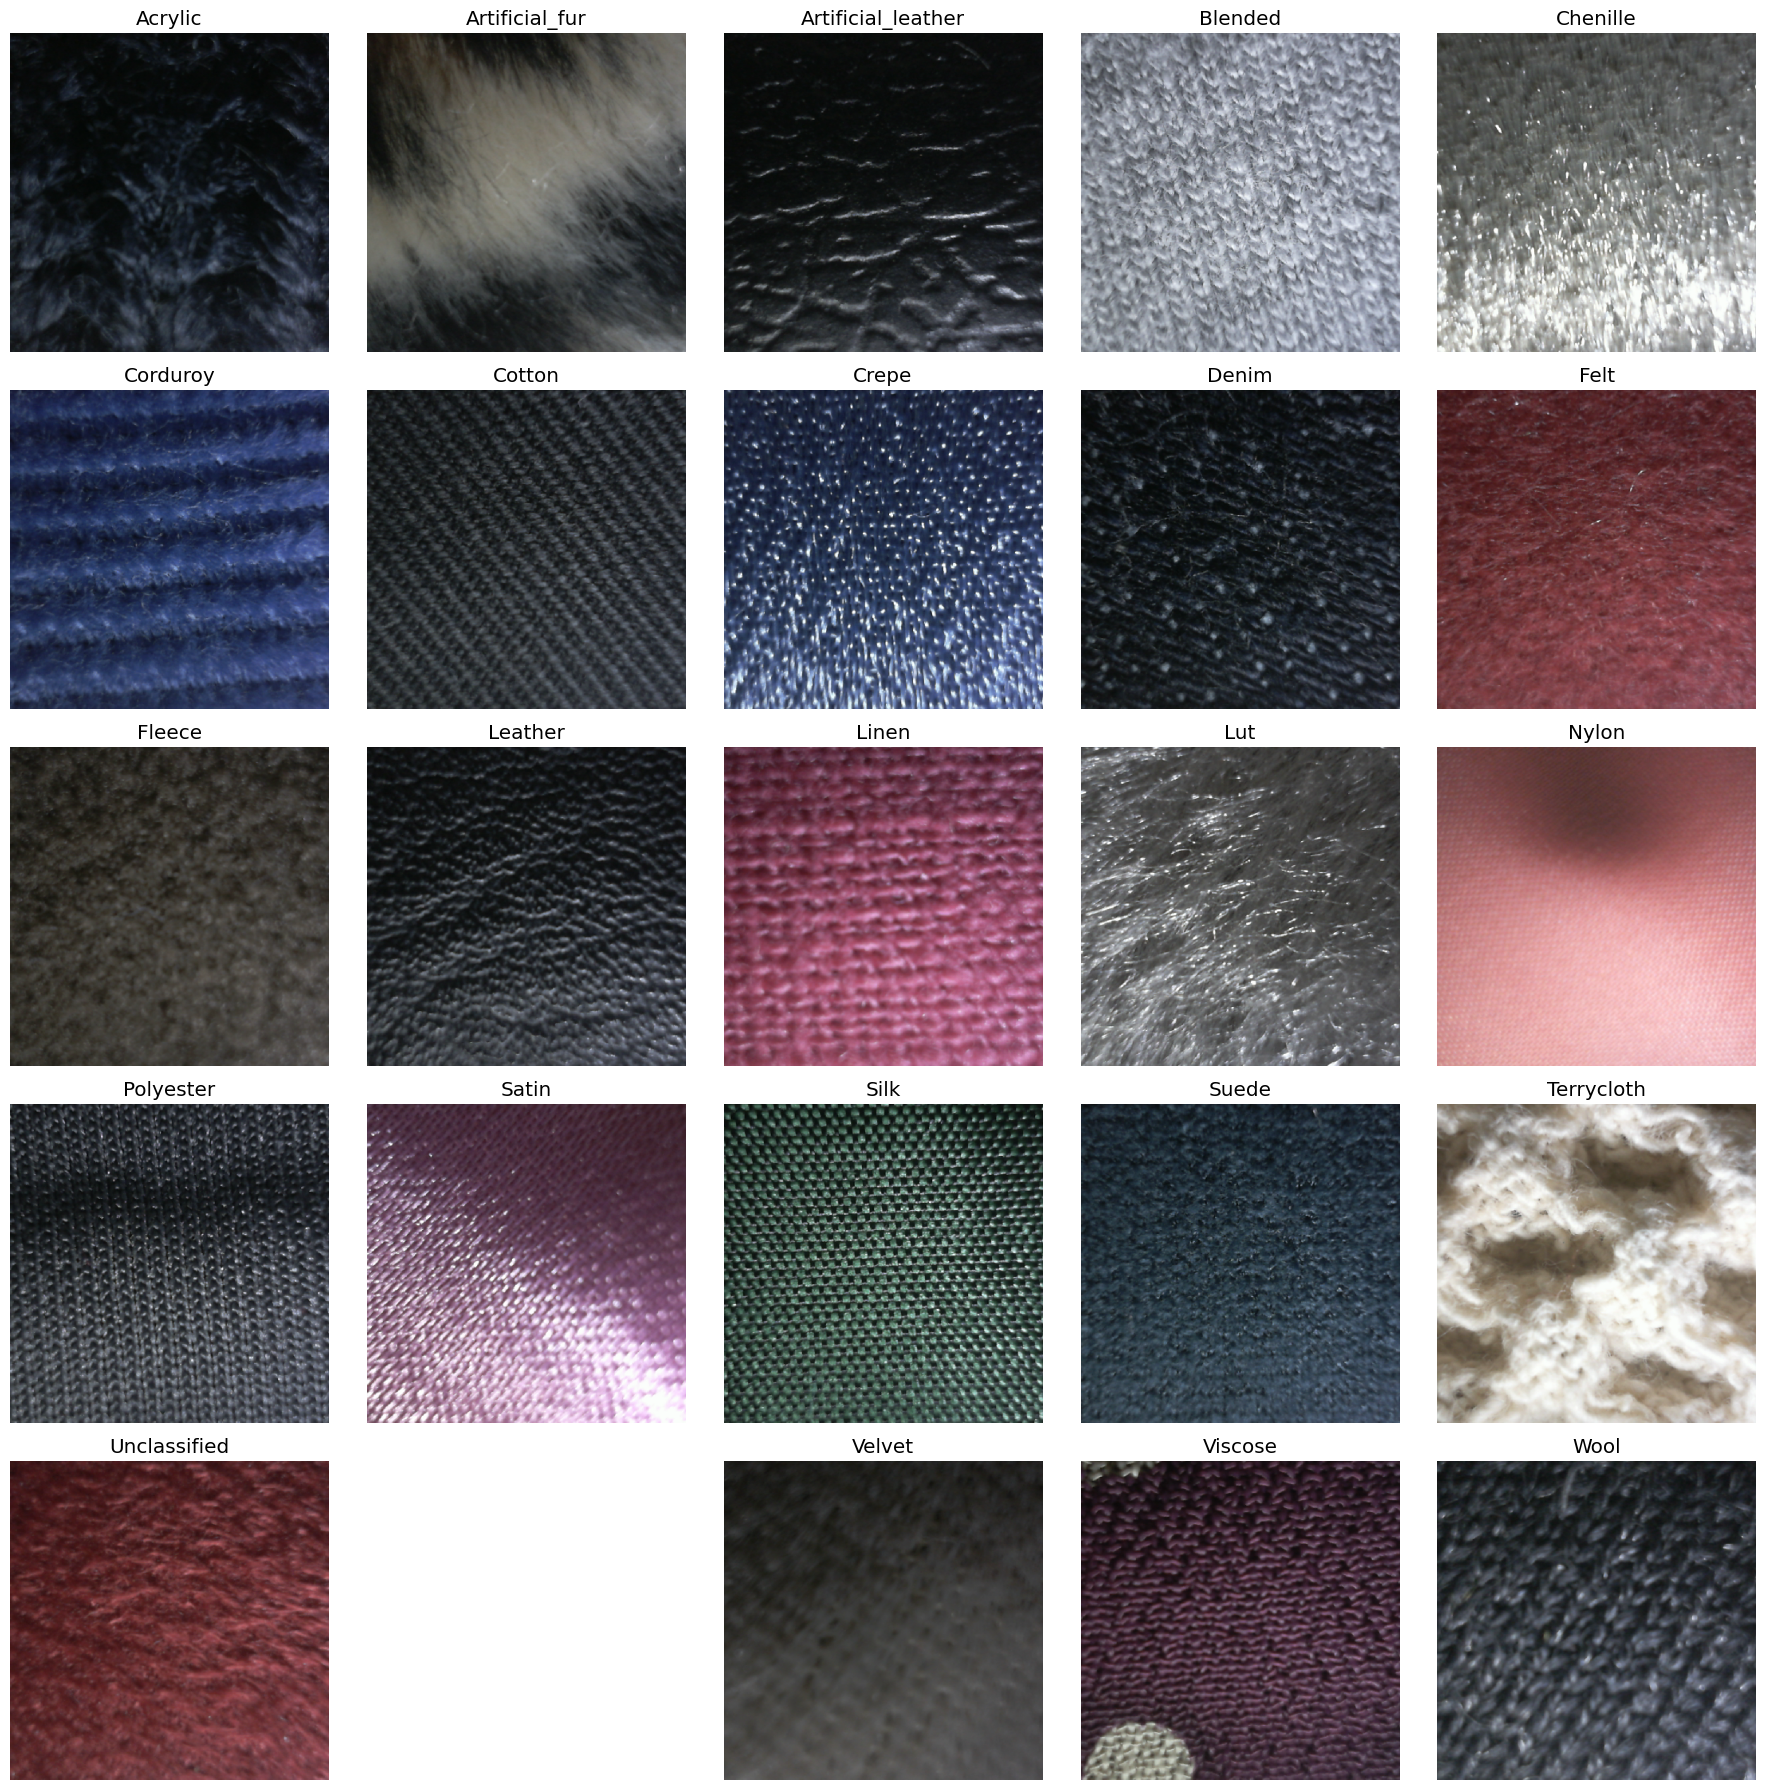

In [ ]:
# Sample Images from Each Fabric Class
import random
from PIL import Image

classes = sorted(os.listdir(FABRIC_DATASET_PATH))

plt.figure(figsize=(18,18))

for i, cls in enumerate(classes):

    sample_folders = [
        f for f in Path(FABRIC_DATASET_PATH, cls).iterdir()
        if f.is_dir()
    ]

    if not sample_folders:
        continue

    sample = random.choice(sample_folders)

    images = list(sample.glob("*.png"))

    if not images:
        continue

    img = Image.open(images[0])

    plt.subplot(5,5,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# Image Resolution Analysis
from pathlib import Path
from PIL import Image

widths = []
heights = []

for class_folder in Path(FABRIC_DATASET_PATH).iterdir():

    if not class_folder.is_dir():
        continue

    for sample in class_folder.iterdir():

        if not sample.is_dir():
            continue

        for img_path in sample.glob("*.png"):

            try:
                img = Image.open(img_path)

                w, h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

In [ ]:
print(f"Total Images : {len(widths)}")

print(f"Minimum Width : {min(widths)}")
print(f"Maximum Width : {max(widths)}")

print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")

print(f"Average Width : {sum(widths)/len(widths):.2f}")
print(f"Average Height : {sum(heights)/len(heights):.2f}")

Total Images : 7881
Minimum Width : 400
Maximum Width : 400
Minimum Height : 400
Maximum Height : 400
Average Width : 400.00
Average Height : 400.00


In [ ]:
# Corrupted Image Detection
from pathlib import Path
from PIL import Image

corrupted_images = []

for class_folder in Path(FABRIC_DATASET_PATH).iterdir():

    if not class_folder.is_dir():
        continue

    for sample_folder in class_folder.iterdir():

        if not sample_folder.is_dir():
            continue

        for img_path in sample_folder.glob("*.png"):

            try:
                img = Image.open(img_path)
                img.verify()

            except Exception:

                corrupted_images.append(str(img_path))

print("Total Corrupted Images :", len(corrupted_images))

if corrupted_images:

    print("\nCorrupted Files:\n")

    for img in corrupted_images:
        print(img)

Total Corrupted Images : 0


In [ ]:
# Multi-View Sample Verification
from pathlib import Path
from PIL import Image
import imagehash
from collections import defaultdict

duplicate_dict = defaultdict(list)

for class_folder in Path(FABRIC_DATASET_PATH).iterdir():

    if not class_folder.is_dir():
        continue

    for sample_folder in class_folder.iterdir():

        if not sample_folder.is_dir():
            continue

        for img_path in sample_folder.glob("*.png"):

            try:

                img = Image.open(img_path)

                img_hash = str(imagehash.phash(img))

                duplicate_dict[img_hash].append(str(img_path))

            except:
                pass

duplicate_groups = {
    h: files
    for h, files in duplicate_dict.items()
    if len(files) > 1
}

print("Duplicate Groups:", len(duplicate_groups))

duplicate_images = sum(len(v) for v in duplicate_groups.values())

print("Duplicate Images:", duplicate_images)

Duplicate Groups: 223
Duplicate Images: 450


In [ ]:
import os

for root, dirs, files in os.walk("/content/defects_dataset"):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-"*50)

/content/defects_dataset
Folders: ['Fabric Defects Dataset']
Files: []
--------------------------------------------------
/content/defects_dataset/Fabric Defects Dataset
Folders: ['Fabric Defect Dataset']
Files: []
--------------------------------------------------
/content/defects_dataset/Fabric Defects Dataset/Fabric Defect Dataset
Folders: ['Vertical', 'horizontal', 'hole', 'lines', 'defect free', 'stain']
Files: []
--------------------------------------------------
/content/defects_dataset/Fabric Defects Dataset/Fabric Defect Dataset/Vertical
Folders: []
Files: ['8.jpg', '1_processed(2).jpg', '1_processed(1).jpg', '14_processed (3).jpg', '3.jpg']
--------------------------------------------------
/content/defects_dataset/Fabric Defects Dataset/Fabric Defect Dataset/horizontal
Folders: []
Files: ['27_processed (1).jpg', '25.jpg', '8.jpg', '29_processed (2).jpg', '3_processed (3).jpg']
--------------------------------------------------
/content/defects_dataset/Fabric Defects Dataset/

In [ ]:
DEFECT_DATASET_PATH = "/content/defects_dataset/Fabric Defects Dataset/Fabric Defect Dataset"

In [ ]:
print(os.listdir(DEFECT_DATASET_PATH))

['Vertical', 'horizontal', 'hole', 'lines', 'defect free', 'stain']


In [ ]:
# Fabric Defect Dataset Analysis
from pathlib import Path
import pandas as pd

defect_counts = {}
total_defect_images = 0

for defect_class in sorted(Path(DEFECT_DATASET_PATH).iterdir()):

    if defect_class.is_dir():

        image_files = []

        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            image_files.extend(defect_class.rglob(ext))

        defect_counts[defect_class.name] = len(image_files)
        total_defect_images += len(image_files)

defect_df = pd.DataFrame(
    defect_counts.items(),
    columns=["Defect Class", "Number of Images"]
)

defect_df = defect_df.sort_values(
    by="Number of Images",
    ascending=False
)

display(defect_df)

print(f"Total Defect Classes: {len(defect_df)}")
print(f"Total Defect Images: {total_defect_images}")

,Defect Class,Number of Images
1,defect free,1666
5,stain,398
2,hole,281
4,lines,157
3,horizontal,136
0,Vertical,101


Total Defect Classes: 6
Total Defect Images: 2739


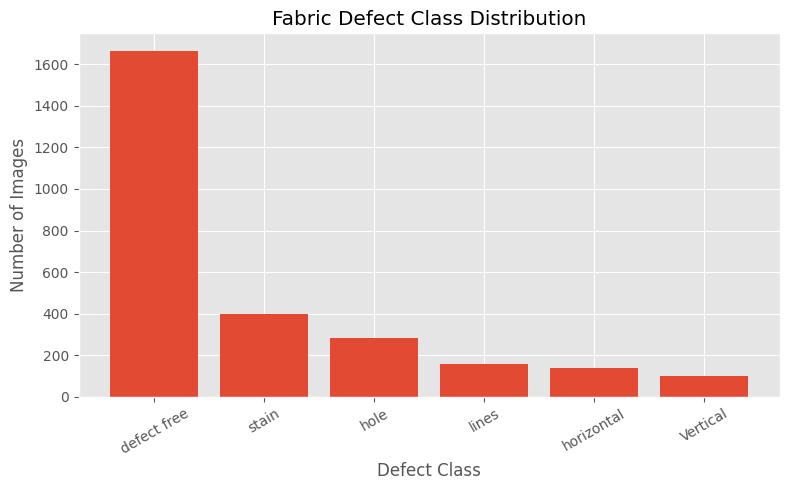

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    defect_df["Defect Class"],
    defect_df["Number of Images"]
)

plt.title("Fabric Defect Class Distribution")

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

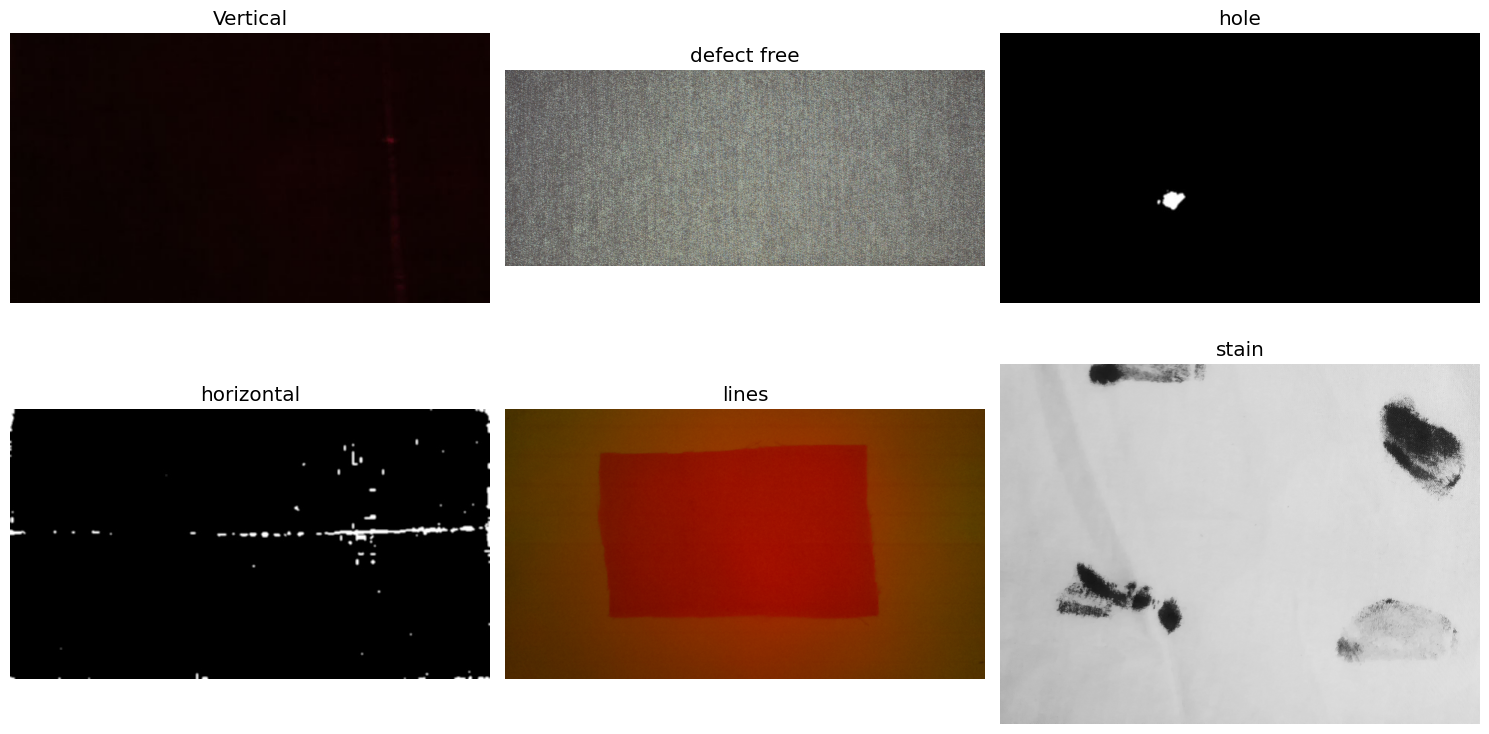

In [ ]:
# Sample Defect Images
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

classes = sorted(os.listdir(DEFECT_DATASET_PATH))

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):

    folder = Path(DEFECT_DATASET_PATH) / cls

    images = []

    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        images.extend(folder.glob(ext))

    if not images:
        continue

    img_path = random.choice(images)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)

    # Display grayscale and RGB correctly
    if img.mode == "L":
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)

    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()


/content/defects_dataset/Fabric Defects Dataset/Fabric Defect Dataset/Vertical/14_processed (1).jpg
L
(640, 360)


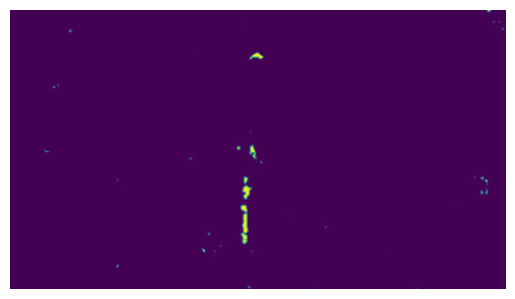

In [ ]:
import random
from pathlib import Path
from PIL import Image

folder = Path(DEFECT_DATASET_PATH) / "Vertical"

img_path = random.choice(list(folder.glob("*.jpg")))

print(img_path)

img = Image.open(img_path)

print(img.mode)
print(img.size)

plt.imshow(img)
plt.axis("off")
plt.show()

# Conclusion

This notebook performed an exploratory data analysis (EDA) on the Fabric Classification and Fabric Defect datasets.

## Fabric Dataset
- 25 fabric classes
- 7,885 images
- Uniform image size (400 × 400 pixels)
- No corrupted images
- Multi-view image samples (4 images per sample)
- Metadata available through tag.txt

## Defect Dataset
- 6 defect classes
- 2,739 images
- Largest class: Defect Free
- Smallest class: Vertical

## Key Findings
- Both datasets are suitable for deep learning.
- The fabric dataset contains metadata that can support further analysis.
- Both datasets are imbalanced and may benefit from data augmentation or class balancing techniques during model training.
- Uniform image resolution simplifies preprocessing for CNN models.

The datasets are now ready for preprocessing and model development.